## Notebook to compare Yolo v11 and FasterR-CNN

### Helper Functions

In [10]:
import os
import json
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO



def load_categories(root_dir):
    """
    Load category names from annotations.json.
    """
    anns_file = os.path.join(root_dir, 'annotations.json')
    if not os.path.exists(anns_file):
        print(f"Error: Annotations file {anns_file} not found")
        return {}
    with open(anns_file, 'r') as f:
        anns = json.load(f)
    return {c['id']: c['name'] for c in anns['categories']}

def get_test_image_paths(output_dir):
    """
    Get list of image paths in the test set.
    """
    test_image_dir = os.path.join(output_dir, 'test', 'images')
    if not os.path.exists(test_image_dir):
        print(f"Error: Test images directory {test_image_dir} not found")
        return []
    return [os.path.join(test_image_dir, img) for img in os.listdir(test_image_dir) if img.endswith(('.jpg', '.jpeg', '.png'))]

def test_on_image(model, image_path, categories, output_dir, conf_threshold=0.5):
    """
    Run inference on a single image, display results, and save annotated image.
    """
    if not os.path.exists(image_path):
        print(f"Error: Image {image_path} not found")
        return

    results = model.predict(image_path, save=False, conf=conf_threshold)
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image {image_path}")
        return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_annotated = img.copy()

    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf = box.conf.item()
            cls = int(box.cls.item())
            label = f"{categories.get(cls, 'unknown')} {conf:.2f}"
            cv2.rectangle(img_annotated, (x1, y1), (x2, y2), (0, 0, 255), 2)
            cv2.putText(img_annotated, label, (x1, max(y1 - 10, 10)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"YOLOv11 Predictions on {os.path.basename(image_path)}")
    plt.show()

    predictions_dir = os.path.join(output_dir, 'predictions')
    os.makedirs(predictions_dir, exist_ok=True)
    output_image_path = os.path.join(predictions_dir, f"pred_{os.path.basename(image_path)}")
    cv2.imwrite(output_image_path, img_annotated)
    print(f"Saved annotated image to: {output_image_path}")

    print(f"Test image: {image_path}")
    print(f"Detected {len(result.boxes)} objects:")
    for box in result.boxes:
        cls = int(box.cls.item())
        conf = box.conf.item()
        print(f" - {categories.get(cls, 'unknown')} at {box.xyxy[0].tolist()} with confidence {conf:.2f}")

In [ ]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import functional as F
from ultralytics import YOLO
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from PIL import Image
import copy
import time

# Configuration
root_dir = ''  # Update with your dataset root path
output_dir = './yolo_chess_dataset'
test_image_dir = os.path.join(output_dir, 'test', 'images')
ann_file = os.path.join(root_dir, 'annotations.json')
yolo_model_path = 'runs/detect/chess_piece_detection/weights/best.pt'
frcnn_model_path = 'faster_rcnn_chess_best.pt'
conf_threshold = 0.7
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
eval_size = 640  # Standardize evaluation to 640x640
dataset_size = 800  # Dataset resizes images to 800x800

# Load categories
def load_categories(root_dir):
    anns_file = os.path.join(root_dir, 'annotations.json')
    if not os.path.exists(anns_file):
        print(f"Error: Annotations file {anns_file} not found")
        return {}
    with open(anns_file, 'r') as f:
        anns = json.load(f)
    categories = {int(c['id']): c['name'] for c in anns.get('categories', [])}
    print(f"Loaded {len(categories)} categories: {categories}")
    return categories

# Get test image paths
def get_test_image_paths(output_dir):
    test_image_dir = os.path.join(output_dir, 'test', 'images')
    if not os.path.exists(test_image_dir):
        print(f"Error: Test images directory {test_image_dir} not found")
        return []
    paths = [os.path.join(test_image_dir, img) for img in os.listdir(test_image_dir) 
             if img.endswith(('.jpg', '.jpeg', '.png'))]
    print(f"Found {len(paths)} test images: {[os.path.basename(p) for p in paths[:5]]}")
    return paths

# Convert YOLO predictions to COCO format
def yolo_to_coco(results, image_id, categories, orig_width, orig_height):
    coco_results = []
    scale_x = eval_size / orig_width
    scale_y = eval_size / orig_height
    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            # Scale to eval_size
            x1, y1, x2, y2 = x1 * scale_x, y1 * scale_y, x2 * scale_x, y2 * scale_y
            # Clamp to image bounds
            x1, x2 = max(0, min(x1, eval_size)), max(0, min(x2, eval_size))
            y1, y2 = max(0, min(y1, eval_size)), max(0, min(y2, eval_size))
            conf = box.conf.item()
            cls = int(box.cls.item())
            if conf >= conf_threshold and cls in categories and x2 > x1 and y2 > y1:
                coco_results.append({
                    'image_id': int(image_id),
                    'category_id': cls,
                    'bbox': [x1, y1, x2 - x1, y2 - y1],
                    'score': conf
                })
    return coco_results

# Convert Faster R-CNN predictions to COCO format
def frcnn_to_coco(predictions, image_id, conf_threshold, categories):
    coco_results = []
    scale_x = eval_size / dataset_size
    scale_y = eval_size / dataset_size
    for box, score, label in zip(predictions['boxes'], predictions['scores'], predictions['labels']):
        cls = label.item()
        if score >= conf_threshold and cls in categories:
            x1, y1, x2, y2 = box.tolist()
            # Scale from dataset_size to eval_size
            x1, y1, x2, y2 = x1 * scale_x, y1 * scale_y, x2 * scale_x, y2 * scale_y
            # Clamp to image bounds
            x1, x2 = max(0, min(x1, eval_size)), max(0, min(x2, eval_size))
            y1, y2 = max(0, min(y1, eval_size)), max(0, min(y2, eval_size))
            if x2 > x1 and y2 > y1:
                coco_results.append({
                    'image_id': int(image_id),
                    'category_id': cls,
                    'bbox': [x1, y1, x2 - x1, y2 - y1],
                    'score': score.item()
                })
    return coco_results

# Generate COCO annotations from YOLO labels
def generate_coco_annotations(dataset, categories, image_ids):
    coco_dataset = {
        'images': [],
        'annotations': [],
        'categories': [{'id': int(k), 'name': v} for k, v in categories.items()]
    }
    ann_id = 1
    for idx in range(len(dataset)):
        img, target, img_path, image_id, orig_width, orig_height = dataset[idx]
        if int(image_id) not in image_ids:
            continue
        img_info = {
            'id': int(image_id),
            'file_name': os.path.basename(img_path),
            'width': eval_size,
            'height': eval_size
        }
        coco_dataset['images'].append(img_info)
        scale_x = eval_size / dataset_size
        scale_y = eval_size / dataset_size
        print(f"Ground truth boxes before scaling (image {image_id}): {target['boxes'].tolist()}")
        for box, label in zip(target['boxes'], target['labels']):
            x_min, y_min, x_max, y_max = box.tolist()
            if label.item() not in categories:
                print(f"Warning: Label {label.item()} not in categories")
                continue
            # Scale from dataset_size to eval_size
            x_min, y_min, x_max, y_max = x_min * scale_x, y_min * scale_y, x_max * scale_x, y_max * scale_y
            # Clamp to image bounds
            x_min, x_max = max(0, min(x_min, eval_size)), max(0, min(x_max, eval_size))
            y_min, y_max = max(0, min(y_min, eval_size)), max(0, min(y_max, eval_size))
            if x_max > x_min and y_max > y_min:
                coco_dataset['annotations'].append({
                    'id': ann_id,
                    'image_id': int(image_id),
                    'category_id': int(label.item()),
                    'bbox': [x_min, y_min, x_max - x_min, y_max - y_min],
                    'area': (x_max - x_min) * (y_max - y_min),
                    'iscrowd': 0
                })
                ann_id += 1
        print(f"Ground truth boxes after scaling (image {image_id}): {[[a['bbox'][0], a['bbox'][1], a['bbox'][2], a['bbox'][3]] for a in coco_dataset['annotations'] if a['image_id'] == int(image_id)]}")
    temp_file = 'temp_coco_annotations.json'
    with open(temp_file, 'w') as f:
        json.dump(coco_dataset, f)
    print(f"Generated COCO annotations with {len(coco_dataset['images'])} images, "
          f"{len(coco_dataset['annotations'])} annotations, "
          f"{len(coco_dataset['categories'])} categories")
    with open(temp_file, 'r') as f:
        anns = json.load(f)
        print(f"Sample ground truth: {anns['annotations'][:2]}")
    return temp_file

# Custom Dataset Class
class ChessDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, output_dir, partition='test', transforms=None):
        self.root_dir = root_dir
        self.output_dir = output_dir
        self.partition = partition
        self.transforms = transforms
        anns_file = os.path.join(root_dir, 'annotations.json')
        if not os.path.exists(anns_file):
            raise FileNotFoundError(f"Annotations file {anns_file} not found")
        with open(anns_file, 'r') as f:
            self.anns = json.load(f)
        self.image_info = {int(img['id']): img for img in self.anns.get('images', [])}
        if 'splits' not in self.anns or 'chessred2k' not in self.anns['splits'] or partition not in self.anns['splits']['chessred2k']:
            print(f"Warning: Split '{partition}' not found. Using all images.")
            self.image_ids = [int(img['id']) for img in self.anns.get('images', [])]
        else:
            split_ids = np.asarray(self.anns['splits']['chessred2k'][partition]['image_ids']).astype(int)
            self.image_ids = [int(img['id']) for img in self.anns.get('images', []) if int(img['id']) in split_ids]
        image_dir = os.path.join(output_dir, partition, 'images')
        label_dir = os.path.join(output_dir, partition, 'labels')
        if not os.path.exists(image_dir) or not os.path.exists(label_dir):
            raise FileNotFoundError(f"Image or label directory missing for {partition}")
        self.image_paths = []
        self.label_paths = []
        for image_id in self.image_ids:
            img_info = self.image_info.get(image_id)
            if img_info is None:
                print(f"Warning: No image info for ID {image_id}")
                continue
            file_name = os.path.basename(img_info['path'])
            img_path = os.path.join(image_dir, file_name)
            label_path = os.path.join(label_dir, os.path.splitext(file_name)[0] + '.txt')
            if os.path.exists(img_path) and os.path.exists(label_path):
                self.image_paths.append(img_path)
                self.label_paths.append(label_path)
            else:
                print(f"Warning: Missing image or label for {image_id}: {img_path}, {label_path}")
        print(f"Dataset {partition}: {len(self.image_paths)} images, {len(self.label_paths)} labels")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label_path = self.label_paths[idx]
        img_info = next((info for info in self.image_info.values() 
                         if os.path.basename(info['path']) == os.path.basename(img_path)), None)
        if img_info is None:
            raise ValueError(f"No image info found for {img_path}")
        
        img = Image.open(img_path).convert('RGB')
        orig_width, orig_height = img.size
        
        boxes = []
        labels = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    try:
                        class_id, center_x, center_y, norm_w, norm_h = map(float, line.strip().split())
                        x_min = (center_x - norm_w / 2) * orig_width
                        y_min = (center_y - norm_h / 2) * orig_height
                        x_max = (center_x + norm_w / 2) * orig_width
                        y_max = (center_y + norm_h / 2) * orig_height
                        if x_min < 0 or y_min < 0 or x_max > orig_width or y_max > orig_height or x_min >= x_max or y_min >= y_max:
                            print(f"Invalid box in {label_path}: [{x_min}, {y_min}, {x_max}, {y_max}]")
                            continue
                        boxes.append([x_min, y_min, x_max, y_max])
                        labels.append(int(class_id))
                    except ValueError:
                        print(f"Error parsing label file {label_path}")
                        continue
        
        if self.transforms:
            img = self.transforms(img)
            new_width, new_height = img.shape[-1], img.shape[-2]
            scale_x = new_width / orig_width
            scale_y = new_height / orig_height
            if boxes:
                boxes = [[x_min * scale_x, y_min * scale_y, x_max * scale_x, y_max * scale_y] 
                         for x_min, y_min, x_max, y_max in boxes]
        
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        image_id = torch.tensor([img_info['id']])
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]) if len(boxes) > 0 else torch.tensor([])
        iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)
        
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': image_id,
            'area': area,
            'iscrowd': iscrowd
        }
        
        return img, target, img_path, img_info['id'], orig_width, orig_height

# Main evaluation function
def evaluate_models():
    # Load categories
    categories = load_categories(root_dir)
    if not categories:
        print("Error: No categories loaded.")
        return

    # Verify image sizes
    test_images = get_test_image_paths(output_dir)
    for img_path in test_images[:5]:  # Limit to first 5 for brevity
        with Image.open(img_path) as img:
            print(f"Image {os.path.basename(img_path)}: actual size {img.size}")

    # Load test dataset
    test_dataset = ChessDataset(root_dir, output_dir, partition='test', 
                               transforms=torchvision.transforms.Compose([
                                   torchvision.transforms.Resize((dataset_size, dataset_size)),
                                   torchvision.transforms.PILToTensor(),
                                   torchvision.transforms.ConvertImageDtype(torch.float32)
                               ]))
    if len(test_dataset) == 0:
        print("Error: No test images found.")
        return
    image_ids = [int(test_dataset[idx][3]) for idx in range(len(test_dataset))]
    print(f"Test image IDs: {image_ids[:5]} (total {len(image_ids)})")

    # Generate COCO annotations
    temp_ann_file = generate_coco_annotations(test_dataset, categories, image_ids)
    coco_gt = COCO(temp_ann_file)
    test_image_ids = coco_gt.getImgIds()
    if not test_image_ids:
        print("Error: No test images in generated annotations.")
        return

    # Initialize models
    yolo_model = YOLO(yolo_model_path)
    frcnn_model = fasterrcnn_resnet50_fpn(weights=None)
    num_classes = len(categories) + 1  # +1 for background
    in_features = frcnn_model.roi_heads.box_predictor.cls_score.in_features
    frcnn_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    frcnn_model.load_state_dict(torch.load(frcnn_model_path, map_location=device))
    frcnn_model.to(device).eval()

    # Collect predictions and inference times
    yolo_results = []
    frcnn_results = []
    yolo_inference_times = []
    frcnn_inference_times = []
    for idx in range(len(test_dataset)):
        img, target, img_path, image_id, orig_width, orig_height = test_dataset[idx]
        image_id = int(image_id)
        print(f"Processing image {img_path} (ID: {image_id}, original size: {orig_width}x{orig_height})")
        print(f"Ground truth: {len(target['boxes'])} boxes, labels: {target['labels'].tolist()}")

        # YOLO inference
        start_time = time.time()
        yolo_preds = yolo_model.predict(img_path, save=False, conf=conf_threshold, imgsz=eval_size)
        yolo_inference_time = (time.time() - start_time) * 1000  # Convert to ms
        yolo_inference_times.append(yolo_inference_time)
        yolo_image_results = yolo_to_coco(yolo_preds, image_id, categories, orig_width, orig_height)
        yolo_results.extend(yolo_image_results)
        print(f"YOLO predictions: {len(yolo_image_results)} {yolo_image_results[:2]}, inference time: {yolo_inference_time:.2f}ms")

        # Faster R-CNN inference
        img_tensor = img.to(device)
        start_time = time.time()
        with torch.no_grad():
            frcnn_preds = frcnn_model([img_tensor])[0]
        frcnn_inference_time = (time.time() - start_time) * 1000  # Convert to ms
        frcnn_inference_times.append(frcnn_inference_time)
        frcnn_image_results = frcnn_to_coco(frcnn_preds, image_id, conf_threshold, categories)
        frcnn_results.extend(frcnn_image_results)
        print(f"Faster R-CNN predictions: {len(frcnn_image_results)} {frcnn_image_results[:2]}, inference time: {frcnn_inference_time:.2f}ms")

    print(f"Total YOLO predictions: {len(yolo_results)}")
    print(f"Total Faster R-CNN predictions: {len(frcnn_results)}")
    mean_yolo_time = np.mean(yolo_inference_times) if yolo_inference_times else 0.0
    mean_frcnn_time = np.mean(frcnn_inference_times) if frcnn_inference_times else 0.0
    print(f"Mean YOLOv11 inference time: {mean_yolo_time:.2f}ms")
    print(f"Mean Faster R-CNN inference time: {mean_frcnn_time:.2f}ms")

    # Evaluate YOLO
    yolo_metrics = {'mAP@0.5': 0.0, 'mAP@0.5:0.95': 0.0, 'F1': 0.0}
    if yolo_results:
        coco_dt_yolo = coco_gt.loadRes(yolo_results)
        coco_eval_yolo = COCOeval(coco_gt, coco_dt_yolo, 'bbox')
        coco_eval_yolo.params.imgIds = test_image_ids
        coco_eval_yolo.evaluate()
        coco_eval_yolo.accumulate()
        coco_eval_yolo.summarize()
        precision = coco_eval_yolo.stats[8] if coco_eval_yolo.stats.size > 8 else 0.0
        recall = coco_eval_yolo.stats[9] if coco_eval_yolo.stats.size > 9 else 0.0
        yolo_metrics = {
            'mAP@0.5': coco_eval_yolo.stats[1] if coco_eval_yolo.stats.size > 1 else 0.0,
            'mAP@0.5:0.95': coco_eval_yolo.stats[0] if coco_eval_yolo.stats.size > 0 else 0.0,
            'F1': 2 * precision * recall / (precision + recall + 1e-6) if precision + recall > 0 else 0.0
        }

    # Evaluate Faster R-CNN
    frcnn_metrics = {'mAP@0.5': 0.0, 'mAP@0.5:0.95': 0.0, 'F1': 0.0}
    if frcnn_results:
        coco_dt_frcnn = coco_gt.loadRes(frcnn_results)
        coco_eval_frcnn = COCOeval(coco_gt, coco_dt_frcnn, 'bbox')
        coco_eval_frcnn.params.imgIds = test_image_ids
        coco_eval_frcnn.evaluate()
        coco_eval_frcnn.accumulate()
        coco_eval_frcnn.summarize()
        precision = coco_eval_frcnn.stats[8] if coco_eval_frcnn.stats.size > 8 else 0.0
        recall = coco_eval_frcnn.stats[9] if coco_eval_frcnn.stats.size > 9 else 0.0
        frcnn_metrics = {
            'mAP@0.5': coco_eval_frcnn.stats[1] if coco_eval_frcnn.stats.size > 1 else 0.0,
            'mAP@0.5:0.95': coco_eval_frcnn.stats[0] if coco_eval_frcnn.stats.size > 0 else 0.0,
            'F1': 2 * precision * recall / (precision + recall + 1e-6) if precision + recall > 0 else 0.0
        }

    # Print results
    print("\nModel Comparison:")
    print(f"{'Metric':<15} {'YOLOv11':<10} {'Faster R-CNN':<12}")
    print("-" * 37)
    for metric in ['mAP@0.5', 'mAP@0.5:0.95', 'F1']:
        print(f"{metric:<15} {yolo_metrics[metric]:<10.4f} {frcnn_metrics[metric]:<12.4f}")
    print(f"{'Mean Inf Time':<15} {mean_yolo_time:<10.2f} {mean_frcnn_time:<12.2f}")

    # Plot results
    metrics = ['mAP@0.5', 'mAP@0.5:0.95', 'F1']
    yolo_values = [yolo_metrics[m] for m in metrics]
    frcnn_values = [frcnn_metrics[m] for m in metrics]
    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width/2, yolo_values, width, label='YOLOv11', color='#36A2EB')
    ax.bar(x + width/2, frcnn_values, width, label='Faster R-CNN', color='#FF6384')
    ax.set_xlabel('Metrics')
    ax.set_ylabel('Values')
    ax.set_title('YOLOv11 vs Faster R-CNN: Performance Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('model_comparison.png')
    plt.close()
    print("Saved comparison plot to 'model_comparison.png'")

if __name__ == '__main__':
    evaluate_models()

Loaded 13 categories: {0: 'white-pawn', 1: 'white-rook', 2: 'white-knight', 3: 'white-bishop', 4: 'white-queen', 5: 'white-king', 6: 'black-pawn', 7: 'black-rook', 8: 'black-knight', 9: 'black-bishop', 10: 'black-queen', 11: 'black-king', 12: 'empty'}
Found 306 test images: ['G000_IMG000.jpg', 'G000_IMG001.jpg', 'G000_IMG002.jpg', 'G000_IMG003.jpg', 'G000_IMG004.jpg']
Image G000_IMG000.jpg: actual size (3072, 3072)
Image G000_IMG001.jpg: actual size (3072, 3072)
Image G000_IMG002.jpg: actual size (3072, 3072)
Image G000_IMG003.jpg: actual size (3072, 3072)
Image G000_IMG004.jpg: actual size (3072, 3072)
Dataset test: 306 images, 306 labels
Test image IDs: [0, 1, 2, 3, 4] (total 306)
Ground truth boxes before scaling (image 0): [[132.9008026123047, 250.9503936767578, 173.46080017089844, 299.42401123046875], [180.2528076171875, 228.4604034423828, 220.48159790039062, 283.5284118652344], [228.39599609375, 212.30479431152344, 262.35919189453125, 265.7239990234375], [271.2627868652344, 183.2

Loading trained model from runs/detect/chess_piece_detection/weights/best.pt
Testing on image: yolo_chess_dataset\test\images\G000_IMG000.jpg

image 1/1 c:\Users\migue\Desktop\Feup\FEUP\MEIC\ano1_semestre2\VC\vcom-proj2\yolo_chess_dataset\test\images\G000_IMG000.jpg: 640x640 8 white-pawns, 2 white-rooks, 2 white-knights, 2 white-bishops, 1 white-queen, 1 white-king, 8 black-pawns, 2 black-rooks, 2 black-knights, 2 black-bishops, 1 black-queen, 1 black-king, 8.5ms
Speed: 4.0ms preprocess, 8.5ms inference, 83.6ms postprocess per image at shape (1, 3, 640, 640)


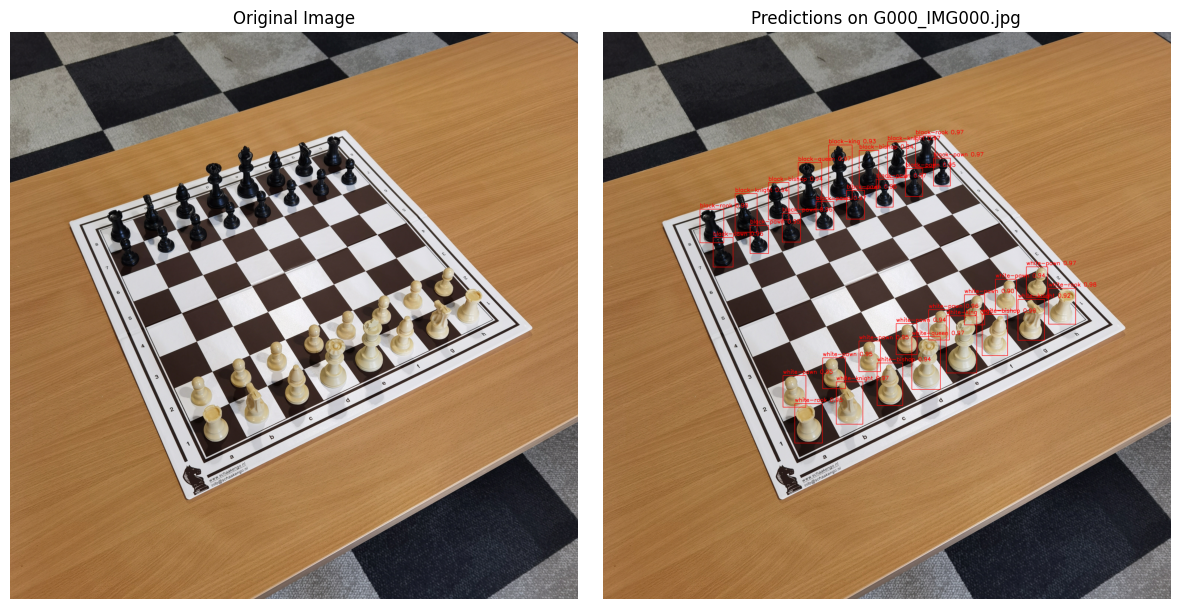

Saved annotated image to: yolo_chess_dataset\predictions\pred_G000_IMG000.jpg
Test image: yolo_chess_dataset\test\images\G000_IMG000.jpg
Detected 32 objects:
 - white-rook at [2410.435546875, 1391.2392578125, 2556.31640625, 1585.6058349609375] with confidence 0.98
 - black-rook at [524.1851196289062, 963.0350341796875, 653.1126098632812, 1145.84228515625] with confidence 0.98
 - white-queen at [1670.716796875, 1653.9818115234375, 1824.3785400390625, 1938.3594970703125] with confidence 0.97
 - black-pawn at [1477.205322265625, 801.9133911132812, 1569.2320556640625, 952.1345825195312] with confidence 0.97
 - white-king at [1856.922607421875, 1540.57421875, 2021.90234375, 1849.4783935546875] with confidence 0.97
 - black-knight at [1538.9376220703125, 599.3533325195312, 1642.3076171875, 793.9320068359375] with confidence 0.97
 - black-queen at [1055.0556640625, 711.1854858398438, 1183.136474609375, 966.1668701171875] with confidence 0.97
 - black-rook at [1690.124755859375, 567.7242431640

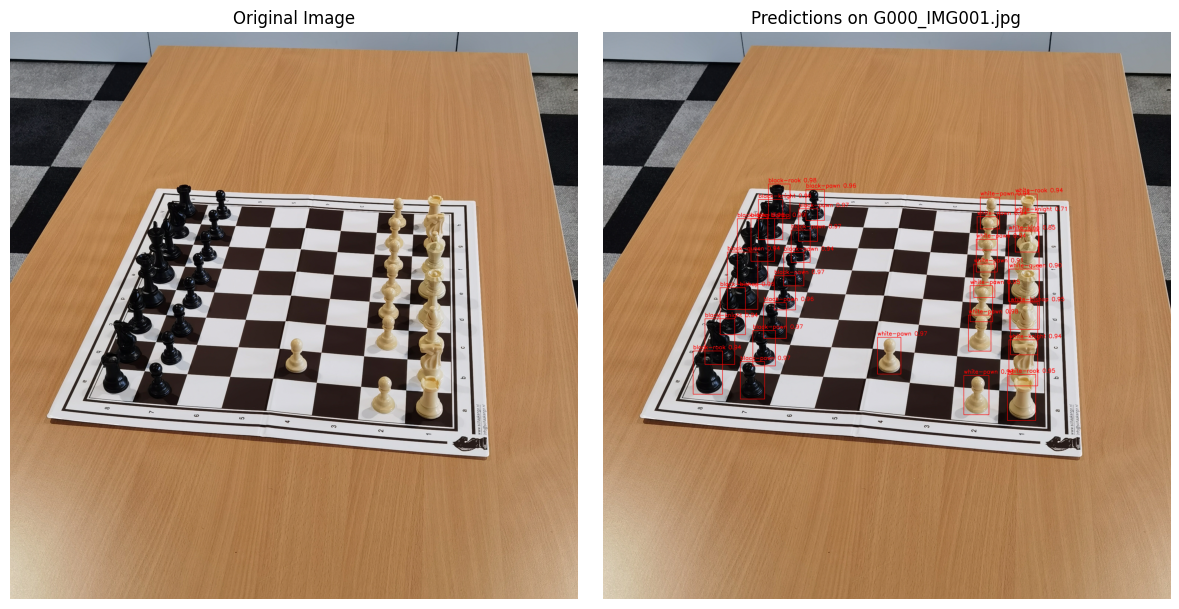

Saved annotated image to: yolo_chess_dataset\predictions\pred_G000_IMG001.jpg
Test image: yolo_chess_dataset\test\images\G000_IMG001.jpg
Detected 31 objects:
 - black-bishop at [800.528076171875, 1014.590087890625, 928.5126342773438, 1245.7861328125] with confidence 0.99
 - white-pawn at [1951.18603515625, 1862.951416015625, 2087.390625, 2075.510009765625] with confidence 0.98
 - white-pawn at [1976.6031494140625, 1536.7965087890625, 2098.899658203125, 1731.3743896484375] with confidence 0.98
 - black-rook at [894.6829223632812, 827.1732788085938, 1011.7743530273438, 1014.5426025390625] with confidence 0.98
 - black-pawn at [742.946044921875, 1788.1422119140625, 874.5530395507812, 1990.0491943359375] with confidence 0.97
 - black-pawn at [926.9281005859375, 1323.9677734375, 1041.5830078125, 1508.5] with confidence 0.97
 - black-pawn at [1058.77490234375, 961.4473266601562, 1160.989990234375, 1137.93896484375] with confidence 0.97
 - black-pawn at [1017.8687133789062, 1076.44140625, 112

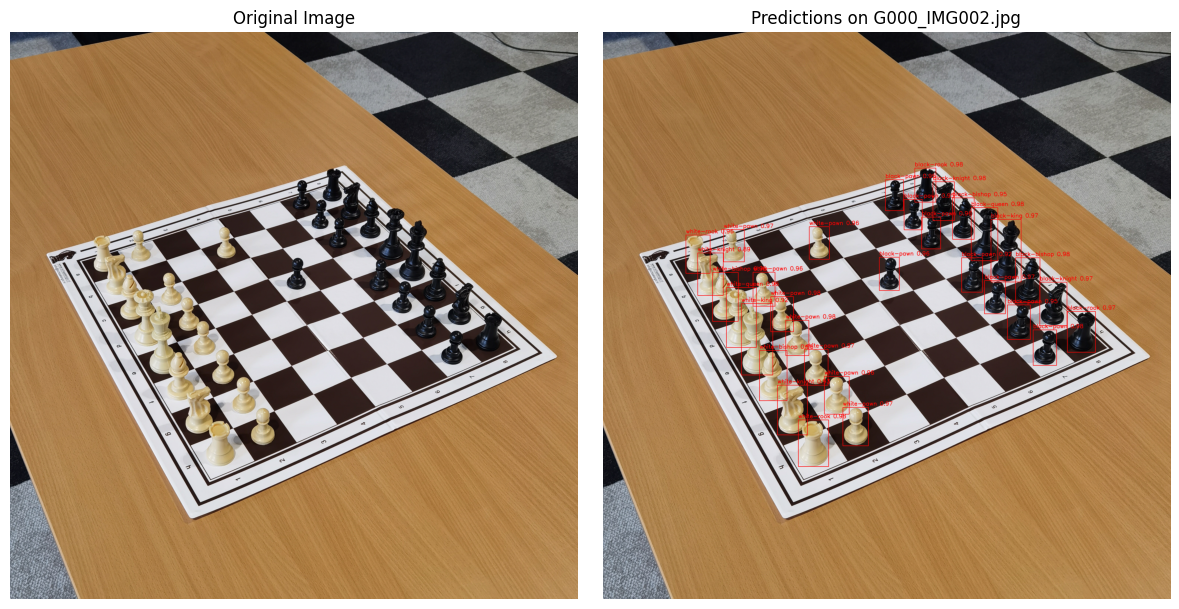

Saved annotated image to: yolo_chess_dataset\predictions\pred_G000_IMG002.jpg
Test image: yolo_chess_dataset\test\images\G000_IMG002.jpg
Detected 32 objects:
 - black-bishop at [2231.82568359375, 1226.13720703125, 2363.6123046875, 1468.00048828125] with confidence 0.98
 - black-rook at [1686.5965576171875, 741.5860595703125, 1800.1351318359375, 925.5679321289062] with confidence 0.98
 - white-pawn at [907.6978149414062, 1436.2520751953125, 1030.031982421875, 1626.7333984375] with confidence 0.98
 - black-queen at [1991.2928466796875, 955.4883422851562, 2135.970458984375, 1242.0736083984375] with confidence 0.98
 - black-pawn at [2326.05419921875, 1616.7515869140625, 2453.396484375, 1808.94677734375] with confidence 0.98
 - white-pawn at [988.3460693359375, 1564.974365234375, 1113.703369140625, 1755.7650146484375] with confidence 0.98
 - black-knight at [1784.1982421875, 815.6644287109375, 1900.5223388671875, 1025.607666015625] with confidence 0.98
 - white-rook at [1056.923095703125, 2

In [2]:
root_dir = ''  # Update with your dataset path
output_dir = 'yolo_chess_dataset'
model_path = 'runs/detect/chess_piece_detection/weights/best.pt'
conf_threshold = 0.7

# Load categories and test images
categories = load_categories(root_dir)
test_image_paths = get_test_image_paths(output_dir)


# Limit to 3 test images or fewer if available
test_image_paths = test_image_paths[:3]
print(f"Loading trained model from {model_path}")
model = YOLO(model_path)

for test_image_path in test_image_paths:
    if not os.path.exists(test_image_path):
        print(f"Error: Image {test_image_path} not found")
        continue

    print(f"Testing on image: {test_image_path}")
    
    # Run inference
    results = model.predict(test_image_path, save=False, conf=conf_threshold)
    
    # Load original image
    img = cv2.imread(test_image_path)
    if img is None:
        print(f"Error: Could not load image {test_image_path}")
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_annotated = img.copy()  # For annotations (BGR)

    # Draw bounding boxes and larger labels
    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf = box.conf.item()
            cls = int(box.cls.item())
            label = f"{categories.get(cls, 'unknown')} {conf:.2f}"
            # Draw rectangle (BGR for OpenCV, red)
            cv2.rectangle(img_annotated, (x1, y1), (x2, y2), (0, 0, 255), 2)
            # Add larger label
            cv2.putText(img_annotated, label, (x1, max(y1 - 10, 10)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2)

    # Convert annotated image to RGB for display
    img_annotated_rgb = cv2.cvtColor(img_annotated, cv2.COLOR_BGR2RGB)
    
    # Display side-by-side comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    ax1.imshow(img_rgb)
    ax1.set_title("Original Image")
    ax1.axis('off')
    ax2.imshow(img_annotated_rgb)
    ax2.set_title(f"Predictions on {os.path.basename(test_image_path)}")
    ax2.axis('off')
    plt.tight_layout()
    plt.show()

    # Save annotated image
    predictions_dir = os.path.join(output_dir, 'predictions')
    os.makedirs(predictions_dir, exist_ok=True)
    output_image_path = os.path.join(predictions_dir, f"pred_{os.path.basename(test_image_path)}")
    cv2.imwrite(output_image_path, img_annotated)
    print(f"Saved annotated image to: {output_image_path}")

    # Print results
    print(f"Test image: {test_image_path}")
    print(f"Detected {len(result.boxes)} objects:")
    for box in result.boxes:
        cls = int(box.cls.item())
        conf = box.conf.item()
        print(f" - {categories.get(cls, 'unknown')} at {box.xyxy[0].tolist()} with confidence {conf:.2f}")